In [ ]:
!pip install yfinance pandas numpy matplotlib scikit-learn tensorflow


In [ ]:
#import pandas as pd

# NASDAQ-listed companies
#url = "https://old.nasdaq.com/screening/companies-by-name.aspx?letter=0&exchange=nasdaq&render=download"
#nasdaq = pd.read_csv(url)
#print(nasdaq[["Symbol", "Name"]].head())

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


# 1. Load Stock Data (e.g., Apple)
ticker = "AAPL"
data = yf.download(ticker, start="2018-01-01", end="2023-01-01")
data = data[["Close"]]

print(data.head())
print(data.count)


/tmp/ipython-input-231636797.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2018-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker           AAPL
Date                 
2018-01-02  40.381001
2018-01-03  40.373966
2018-01-04  40.561504
2018-01-05  41.023308
2018-01-08  40.870926
<bound method DataFrame.count of Price            Close
Ticker            AAPL
Date                  
2018-01-02   40.381001
2018-01-03   40.373966
2018-01-04   40.561504
2018-01-05   41.023308
2018-01-08   40.870926
...                ...
2022-12-23  130.026215
2022-12-27  128.221664
2022-12-28  124.287155
2022-12-29  127.807526
2022-12-30  128.123047

[1259 rows x 1 columns]>


In [ ]:

# 2. Normalize Data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
print(scaled_data)


[[0.04528407]
 [0.04523543]
 [0.04653228]
 ...
 [0.62550504]
 [0.64984881]
 [0.65203068]]


In [ ]:
# 3. Create Sequences
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 60

X, y = create_sequences(scaled_data, SEQ_LEN)
print(X)
print(y)



[[[0.04528407]
  [0.04523543]
  [0.04653228]
  ...
  [0.04725266]
  [0.04004215]
  [0.03701476]]

 [[0.04523543]
  [0.04653228]
  [0.0497257 ]
  ...
  [0.04004215]
  [0.03701476]
  [0.03913062]]

 [[0.04653228]
  [0.0497257 ]
  [0.04867196]
  ...
  [0.03701476]
  [0.03913062]
  [0.03734033]]

 ...

 [[0.73579524]
  [0.76064339]
  [0.76268544]
  ...
  [0.66771431]
  [0.66519131]
  [0.65271263]]

 [[0.76064339]
  [0.76268544]
  [0.75608223]
  ...
  [0.66519131]
  [0.65271263]
  [0.62550504]]

 [[0.76268544]
  [0.75608223]
  [0.71972911]
  ...
  [0.65271263]
  [0.62550504]
  [0.64984881]]]
[[0.03913062]
 [0.03734033]
 [0.04012359]
 ...
 [0.62550504]
 [0.64984881]
 [0.65203068]]


In [ ]:
# 4. Train-Test Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 5. Build LSTM Model
model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(SEQ_LEN, 1)),
    Dense(1)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0838
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0042
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 8.3273e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 7.5461e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 6.9016e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.5969e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.3177e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 7.2028e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.5711e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 5.6789e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 5.8164e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 6.4653e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.3388e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.6258e-04
Epoch 15/20
30/30 ━━━━━

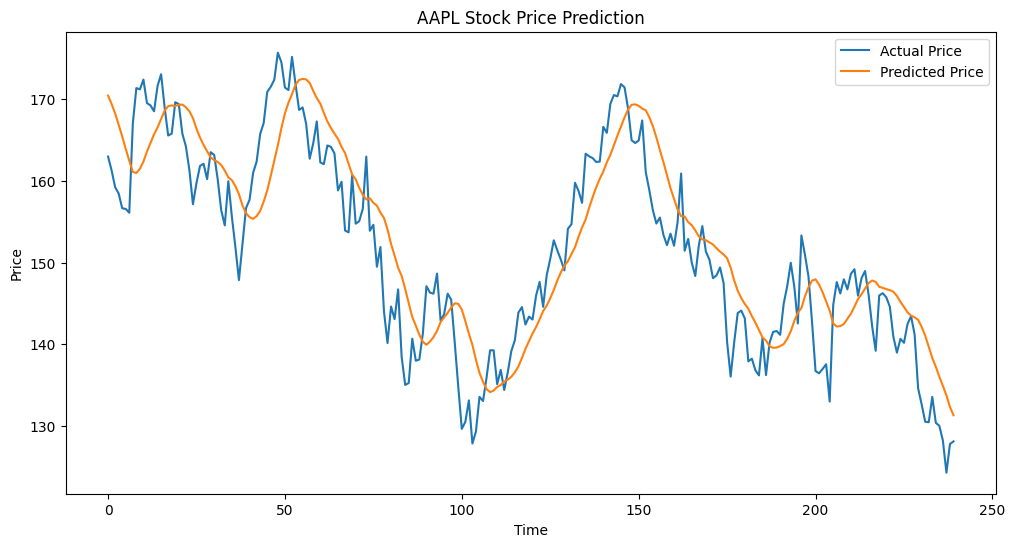

In [ ]:
model.compile(optimizer="adam", loss="mse")
model.fit(X_train, y_train, epochs=20, batch_size=32)

print (X_test)
# 6. Predict and Inverse Transform
predicted = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y_test)

# 7. Plot Results
plt.figure(figsize=(12,6))
plt.plot(actual_prices, label="Actual Price")
plt.plot(predicted_prices, label="Predicted Price")
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()